# El Paso County Climate Coding Challenge Part 5


In [19]:
# import stored variables
%store -r

In [ ]:
#import libraries
import holoviews as hv ### save interactive plots
import hvplot.pandas ### make interactive plots
import pandas as pd
import os 
import matplotlib.pyplot as plt
import os


In [28]:
#Check stored variables 

plot_yearly_avg
elpaso_df
yearly_avg

,Temp_F,Temp_C
Date,,
1895-12-31,66.0,18.888889
1896-12-31,67.3,19.611111
1897-12-31,65.8,18.777778
1898-12-31,68.4,20.222222
1899-12-31,68.5,20.277778
...,...,...
2022-12-31,69.5,20.833333
2023-12-31,69.7,20.944444
2024-12-31,71.2,21.777778


## Regression Analysis

Before we get started, it’s important to consider that OLS regression is
not always the right technique, because it makes some important
assumptions about our data:

**Random error**  
Variation in temperature can be caused by many things beyond global
climate change. For example, temperatures often vary with patterns of
ocean surface temperatures (*teleconnections*), the most famous of which
are El Niño and La Niña. By using a linear OLS regression, we’re
assuming that all the variation in temperature except for climate change
is random.

**Normally distributed data**  
If you have taken a statistics class, you probably learned a lot about
the normal, or Gaussian distribution. For right now, what you need to
know is that OLS regression is useful for identifying trends in average
temperature, but wouldn’t be appropriate for looking at trends in daily
precipitation (because most days have zero precipitation), or at maximum
or minimum annual temperatures (because these are extreme values, and
the normal distribution tends to underestimate the likelihood of large
events).

**Linearity**  
We’re assuming that temperatures are increasing or decreasing at a
constant rate over time. We wouldn’t be able to look at rates that
change over time. For example, many locations in the Arctic remained the
same temperature for much longer than the rest of the world, because ice
melt was absorbing all the extra heat. Linear OLS regression wouldn’t be
able to identify when the temperature rise began on its own.

**Stationarity**  
We’re assuming that variation in temperature caused by things *other*
than global climate change (e.g. the random error) behaves the same over
time. For example, the linear OLS regression can’t take increased
variability from year to year into account, which is a common effect of
climate change. We often see “global weirding”, or more extreme head
*and* cold, in addition to overall increases. You can observe this most
easily by looking at your daily data again. Does it seem to be fanning
in or out over time?

It’s pretty rare to encounter a perfect statistical model where all the
assumptions are met, but you want to be on the lookout for serious
discrepancies, especially when making predictions. For example,
[ignoring assumptions about Gaussian error arguably led to the 2008
financial crash](https://www.wired.com/2009/02/wp-quant/).

### Assumption thoughts for our analysis:

**Random error:**
Though we assume that all error beyond climate change is random, as mentioned above there are other factors that may directly influence temperature change such as shifting teleconnections (seasonal weather patterns).

**Stationarity:**
Fanning patterns across time within El Paso County annual temperature data seems to shift in ~40 year periods. 1900-1940 shows high variability and minima maxima extremes, charecteristic to temperature trends in the state during that period (Ie: Boulder annual temperature data). After 1940 data seems to have an inward fanning trend, however, around 1990 varyability between minima and maxima extremes increase. This may be due to factors outside of the assumed generalized climate change affect such as increase large-scale development, and loss of green space. 

**Linearity:**
There is a clear trend of warming seen from 1900-2023. However extreme shifts in ~1930 disturp the linear trend, and influence the regression, potentially leading a less steep trendline slope than what would be present without those extreme cold periods.


**Gaussian Distribution:**
Data seems to be normally distributed, though with a slight skew towards the warmer extreme values.  

In [ ]:
# Import libraries for regression and plotting
### advanced options on matplotlib/seaborn/pandas plots
import matplotlib.pyplot as plt
### common statistical plots for tabular data
import seaborn as sns
### fit an OLS linear regression
from sklearn.linear_model import LinearRegression

In [37]:
### fit an OLS Linear Regression to the data

### define independent variable
### reshape 'year' to be a 2D array for scikit-learn
ind_variable = yearly_avg.index.year.values.reshape(-1, 1)
### define dependent variable
dep_variable = yearly_avg['Temp_C']

### make linear regression model
model = LinearRegression()

### fit the model on the data
model.fit(ind_variable, dep_variable)

### calculate and print metrics
print(f'Slope: {model.coef_[0]} degrees per year')

Slope: 0.007832732420920455 degrees per year


In [ ]:
# Get current working directory so you know where to save your figure
os.getcwd()

'/Users/davidwilcox/Desktop/01-climate-fall'

<>:15: SyntaxWarning: invalid escape sequence '\c'
<>:15: SyntaxWarning: invalid escape sequence '\c'
/var/folders/hl/l52pw3jj3ggc13gqlmtsqw_w0000gn/T/ipykernel_66131/528468545.py:15: SyntaxWarning: invalid escape sequence '\c'
  ylabel = 'Temperature ($^\circ$C)',


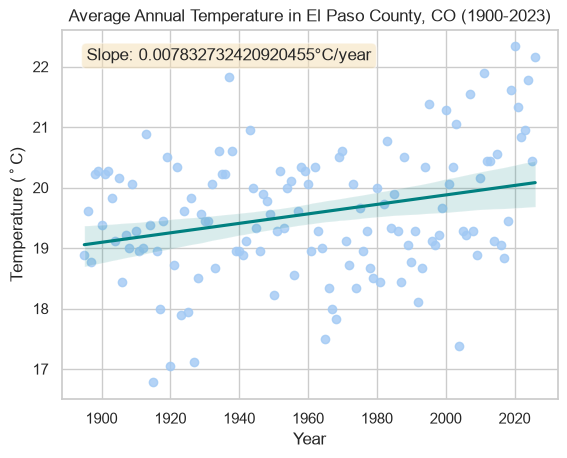

In [46]:
### plot data
# Change style using seaborn style, and pallete options.
# Change trendline color to stand out from scatter points.
sns.set_theme(style="whitegrid", palette="pastel")
ax = sns.regplot(
    x = yearly_avg.index.year, 
    y = yearly_avg['Temp_C'],
    line_kws = {'color': 'teal'} #set line color so it stands out from scatter plot data
)

### make labels
ax.set(
    title = 'Average Annual Temperature in El Paso County, CO (1900-2023)',
    xlabel = 'Year',
    ylabel = 'Temperature ($^\circ$C)',
)
# Add trendline slope as an annotation on plot
ax.text(0.05, 0.95, f'Slope: {model.coef_[0]}°C/year',
        transform=ax.transAxes, fontsize=12,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

### save your plot
plt.savefig('/Users/davidwilcox/Desktop/01-climate-fall/ElPaso_ann_temp.jpeg')
### plot it
plt.show()

#Do seaborn styles to change color etc. 

In [29]:
# Select a subset of the data for the years 1980-2023 for another regression analysis

elpaso_1980_2023 = yearly_avg.loc['1980':'2023']

In [41]:
### fit an OLS Linear Regression to the data

### define independent variable
### reshape 'year' to be a 2D array for scikit-learn
ind_variable_1 = elpaso_1980_2023.index.year.values.reshape(-1, 1)
### define dependent variable
dep_variable_1 = elpaso_1980_2023['Temp_C']

### make linear regression model
model_1 = LinearRegression()

### fit the model on the data
model_1.fit(ind_variable_1, dep_variable_1)

### calculate and print metrics
print(f'Slope: {model_1.coef_[0]} degrees per year')

Slope: 0.0323349776838149 degrees per year


<>:15: SyntaxWarning: invalid escape sequence '\c'
<>:15: SyntaxWarning: invalid escape sequence '\c'
/var/folders/hl/l52pw3jj3ggc13gqlmtsqw_w0000gn/T/ipykernel_66131/2811668808.py:15: SyntaxWarning: invalid escape sequence '\c'
  ylabel = 'Temperature ($^\circ$C)',


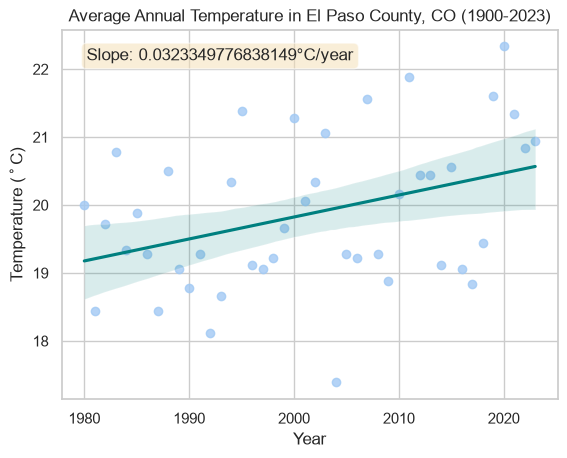

In [45]:
### plot data
# Change style using seaborn style, and pallete options.
# Change trendline color to stand out from scatter points.
sns.set_theme(style="whitegrid", palette="pastel")
ax = sns.regplot(
    x = elpaso_1980_2023.index.year, 
    y = elpaso_1980_2023['Temp_C'],
    line_kws = {'color': 'teal'} #set line color so it stands out from scatter plot data
)

### make labels
ax.set(
    title = 'Average Annual Temperature in El Paso County, CO (1900-2023)',
    xlabel = 'Year',
    ylabel = 'Temperature ($^\circ$C)',
)
slope = model.coef_[0]
# Add trendline slope as an annotation on plot
ax.text(0.05, 0.95, f'Slope: {model_1.coef_[0]}°C/year',
        transform=ax.transAxes, fontsize=12,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
### save your plot (change your path to your own directory)
plt.savefig('/Users/davidwilcox/Desktop/01-climate-fall/ElPaso_ann_temp_1980_2023.jpeg')
### plot it
plt.show()

#Do seaborn styles to change color etc. 

### Anuual Temperature in El Paso County, CO (1900-2023), shows clear trend of warming throughout time, despite El Nino-Southern Oscillation (ENSO) fluctuations. 

A consistent warming trend is shown through analysis of temperature data time-series. With a OLS regression analysis exhibiting a slope of 0.007832732420920455 Which communicates a warming trend of degrees per year.

When doing the same regression analysis over 1980-2023 we can see the warmer trend is even greater, with a trendline slope of 0.0323349776838149, which communicates a warming trend of 0.0323349776838149 degrees celsius per year. 

This is likely due to the omission of cold extremes seen before 1980, which lead to the dampening of the trendline slope in the longer time series analysis. 